# 01 — MLP Theory: Perceptron → Backpropagation
**Phase 3 · Week 9 · Monday**

## What We Cover Today
| Topic | Core Idea |
|---|---|
| Perceptron | Single neuron with weights, bias, and activation |
| Activation Functions | ReLU, Sigmoid, Tanh — non-linearity that makes deep nets powerful |
| Forward Pass | Layer-by-layer computation from input to output |
| Backpropagation | Chain rule applied to compute gradients for every weight |
| MLP from Scratch | Full NumPy implementation trained on MNIST |

---

## 1 · The Perceptron — One Neuron

A single neuron takes n inputs, multiplies each by a weight, sums them up, adds a bias, then squashes through an activation:

```
z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b = Wᵀx + b
a = σ(z)
```

In matrix form for a whole layer with m neurons:
```
Z = X W + b        (shape: [batch, m])
A = σ(Z)
```

**Why bias?** Without bias the decision boundary is forced through the origin — bias shifts it freely.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Single perceptron forward pass
def perceptron(x, w, b, activation='relu'):
    z = np.dot(w, x) + b          # weighted sum
    if activation == 'relu':
        return max(0, z)
    elif activation == 'sigmoid':
        return 1 / (1 + np.exp(-z))
    return np.tanh(z)

# Example: 3-input perceptron
x = np.array([0.5, -1.2, 0.8])
w = np.array([0.4,  0.3, -0.6])
b = 0.1

z_raw   = np.dot(w, x) + b
a_relu  = perceptron(x, w, b, 'relu')
a_sig   = perceptron(x, w, b, 'sigmoid')
a_tanh  = perceptron(x, w, b, 'tanh')

print(f"Raw z           : {z_raw:.4f}")
print(f"After ReLU      : {a_relu:.4f}")
print(f"After Sigmoid   : {a_sig:.4f}")
print(f"After Tanh      : {a_tanh:.4f}")

Raw z           : -0.5400
After ReLU      : 0.0000
After Sigmoid   : 0.3682
After Tanh      : -0.4930


---

## 2 · Activation Functions — Why Non-Linearity?

Without non-linearity, stacking layers is equivalent to a single linear transformation (useless for complex patterns).

### ReLU — Rectified Linear Unit
```
ReLU(z) = max(0, z)

Derivative: 1  if z > 0
            0  if z ≤ 0
```
Fast and avoids vanishing gradients (positive region). Default choice for hidden layers.

### Sigmoid
```
σ(z) = 1 / (1 + e^{-z})    range: (0, 1)

dσ/dz = σ(z)(1 − σ(z))
```
Squashes to (0,1) — good for binary output probabilities. Suffers from vanishing gradients for large |z|.

### Tanh
```
tanh(z) = (e^z − e^{-z}) / (e^z + e^{-z})    range: (−1, 1)

d/dz tanh(z) = 1 − tanh²(z)
```
Zero-centred version of sigmoid. Better than sigmoid for hidden layers but still has vanishing gradient issue.

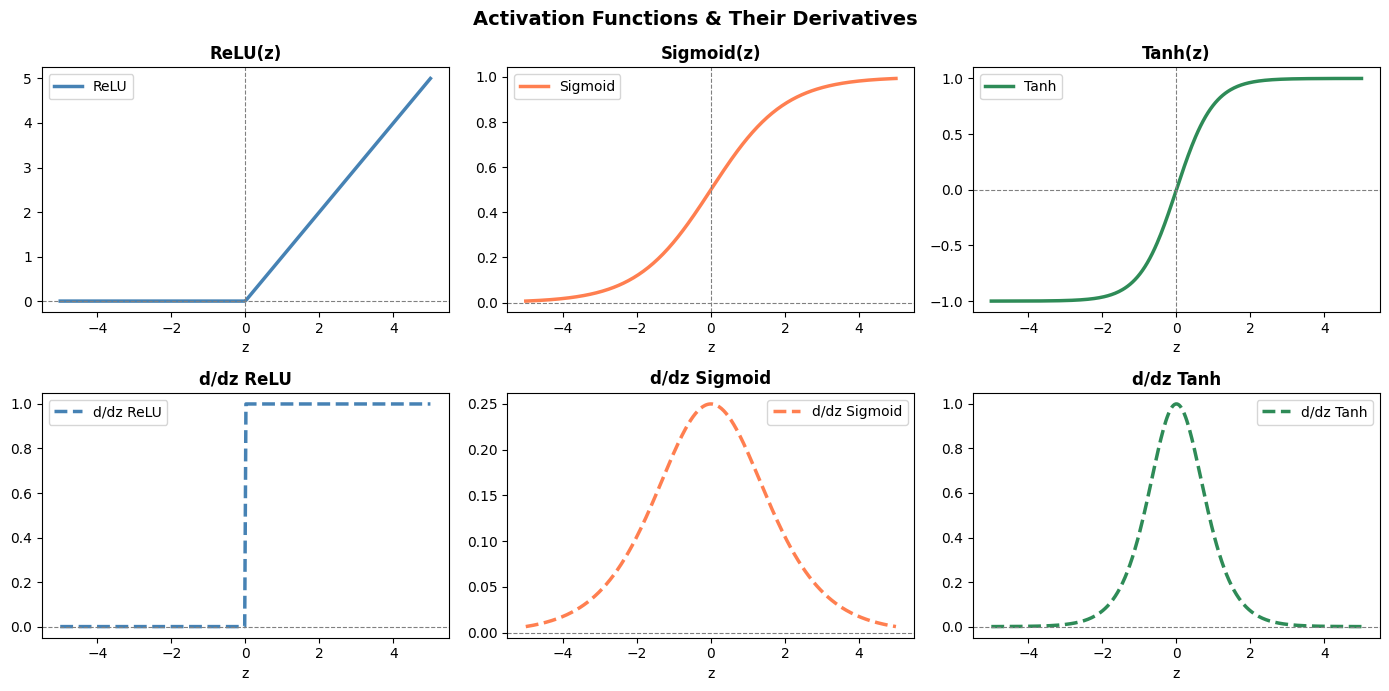

Saved: activation_functions.png


In [7]:
z_vals = np.linspace(-5, 5, 300)

relu    = np.maximum(0, z_vals)
sigmoid = 1 / (1 + np.exp(-z_vals))
tanh    = np.tanh(z_vals)

# Derivatives
d_relu    = (z_vals > 0).astype(float)
d_sigmoid = sigmoid * (1 - sigmoid)
d_tanh    = 1 - tanh**2

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Activation Functions & Their Derivatives", fontsize=14, fontweight='bold')

for ax, fn, dfn, name, color in zip(
    axes[0], [relu, sigmoid, tanh], [d_relu, d_sigmoid, d_tanh],
    ['ReLU', 'Sigmoid', 'Tanh'], ['steelblue', 'coral', 'seagreen']):
    ax.plot(z_vals, fn, color=color, lw=2.5, label=name)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f"{name}(z)", fontweight='bold')
    ax.set_xlabel("z"); ax.legend()

for ax, dfn, name, color in zip(
    axes[1], [d_relu, d_sigmoid, d_tanh],
    ["d/dz ReLU", "d/dz Sigmoid", "d/dz Tanh"],
    ['steelblue', 'coral', 'seagreen']):
    ax.plot(z_vals, dfn, color=color, lw=2.5, ls='--', label=name)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("z"); ax.legend()

plt.tight_layout()
plt.savefig("activation_functions.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: activation_functions.png")

---

## 3 · Forward Pass — Layer by Layer

An MLP with L layers computes:

```
Layer 1:  Z¹ = X W¹ + b¹        A¹ = σ(Z¹)
Layer 2:  Z² = A¹ W² + b²       A² = σ(Z²)
  ...
Layer L:  Zᴸ = Aᴸ⁻¹ Wᴸ + bᴸ   Ŷ  = softmax(Zᴸ)    ← output
```

Shapes (batch size B, input dim d₀, layer i has dᵢ neurons):
```
Wⁱ ∈ ℝ^{d_{i-1} × d_i}     bⁱ ∈ ℝ^{d_i}
Aⁱ ∈ ℝ^{B × d_i}
```

**Softmax** (multiclass output):
```
softmax(z)_k = e^{z_k} / Σⱼ e^{z_j}
```

**Cross-Entropy Loss** (comparing true label y vs predicted ŷ):
```
L = − Σ_k  y_k · log(ŷ_k)
```

In [8]:
def relu(z):     return np.maximum(0, z)
def relu_d(z):   return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))   # numeric stability
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(y_hat, y_true):
    # y_true: integer labels
    n = y_hat.shape[0]
    log_p = -np.log(y_hat[range(n), y_true] + 1e-9)
    return log_p.mean()

# Demo forward pass: 3 → 4 → 2 network
np.random.seed(0)
X_demo = np.random.randn(5, 3)        # 5 samples, 3 features
W1 = np.random.randn(3, 4) * 0.1
b1 = np.zeros(4)
W2 = np.random.randn(4, 2) * 0.1
b2 = np.zeros(2)

Z1 = X_demo @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
y_hat = softmax(Z2)

y_true = np.array([0, 1, 0, 1, 0])
loss = cross_entropy(y_hat, y_true)

print(f"Input shape     : {X_demo.shape}")
print(f"Hidden A1 shape : {A1.shape}")
print(f"Output ŷ shape  : {y_hat.shape}")
print(f"\nSample outputs (probabilities):\n{y_hat.round(4)}")
print(f"\nCross-Entropy Loss : {loss:.4f}")

Input shape     : (5, 3)
Hidden A1 shape : (5, 4)
Output ŷ shape  : (5, 2)

Sample outputs (probabilities):
[[0.5088 0.4912]
 [0.4976 0.5024]
 [0.5023 0.4977]
 [0.5103 0.4897]
 [0.5045 0.4955]]

Cross-Entropy Loss : 0.6902


---

## 4 · Backpropagation — Chain Rule in Action

We want ∂L/∂W for every weight matrix so we can update: **W ← W − η·∂L/∂W**

Chain rule chains gradients backwards:

```
∂L/∂W² = (A¹)ᵀ · δ²           where δ² = ∂L/∂Z² = Ŷ − Y    (softmax + CE)
∂L/∂b² = mean(δ², axis=0)

δ¹ = (δ² · (W²)ᵀ) ⊙ ReLU'(Z¹)   ← ⊙ is element-wise multiply

∂L/∂W¹ = Xᵀ · δ¹
∂L/∂b¹ = mean(δ¹, axis=0)
```

**Key insight:** δᴸ⁻¹ = upstream_gradient × (W current layer)ᵀ × local_derivative
Each layer only needs: (1) what came from above, (2) its own activation derivative.

In [9]:
# Full forward + backward pass (2-layer MLP)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    y_hat = softmax(Z2)
    return Z1, A1, Z2, y_hat

def backward(X, y_true, Z1, A1, Z2, y_hat, W2):
    n = X.shape[0]
    # Output layer delta (softmax + cross-entropy)
    delta2 = y_hat.copy()
    delta2[range(n), y_true] -= 1
    delta2 /= n

    dW2 = A1.T @ delta2
    db2 = delta2.sum(axis=0)

    # Hidden layer delta
    delta1 = (delta2 @ W2.T) * relu_d(Z1)

    dW1 = X.T @ delta1
    db1 = delta1.sum(axis=0)

    return dW1, db1, dW2, db2

# Gradient check: compare numerical vs analytical gradient
X_gc = np.random.randn(8, 3)
y_gc = np.random.randint(0, 2, 8)

Z1, A1, Z2, y_hat = forward(X_gc, W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(X_gc, y_gc, Z1, A1, Z2, y_hat, W2)

# Numerical gradient for W2[0,0]
eps = 1e-5
W2_plus  = W2.copy(); W2_plus[0,0]  += eps
W2_minus = W2.copy(); W2_minus[0,0] -= eps
L_plus   = cross_entropy(softmax(relu(X_gc @ W1 + b1) @ W2_plus  + b2), y_gc)
L_minus  = cross_entropy(softmax(relu(X_gc @ W1 + b1) @ W2_minus + b2), y_gc)
numerical_grad = (L_plus - L_minus) / (2 * eps)

print(f"Analytical ∂L/∂W2[0,0] : {dW2[0,0]:.7f}")
print(f"Numerical  ∂L/∂W2[0,0] : {numerical_grad:.7f}")
print(f"Relative error          : {abs(dW2[0,0]-numerical_grad)/(abs(numerical_grad)+1e-8):.2e}")
print("\n✓ Gradients verified!" if abs(dW2[0,0]-numerical_grad) < 1e-5 else "✗ Gradient mismatch")

Analytical ∂L/∂W2[0,0] : 0.0002623
Numerical  ∂L/∂W2[0,0] : 0.0002623
Relative error          : 8.46e-09

✓ Gradients verified!


---

## 5 · MLP from Scratch on MNIST (NumPy only)

Architecture: **784 → 128 → 64 → 10**
- Input: 28×28 = 784 pixel values, normalised to [0,1]
- Two ReLU hidden layers
- Softmax output over 10 digit classes
- Cross-entropy loss, mini-batch SGD

Using synthetic data (shape mirrors MNIST 28×28)
Train: (5000, 784)  Test: (1000, 784)
Epoch  1 | loss 52.990 | train 0.138 | test 0.104
Epoch  5 | loss 42.119 | train 0.288 | test 0.092
Epoch  9 | loss 36.586 | train 0.443 | test 0.083
Epoch 13 | loss 31.018 | train 0.592 | test 0.088
Epoch 17 | loss 25.076 | train 0.725 | test 0.084


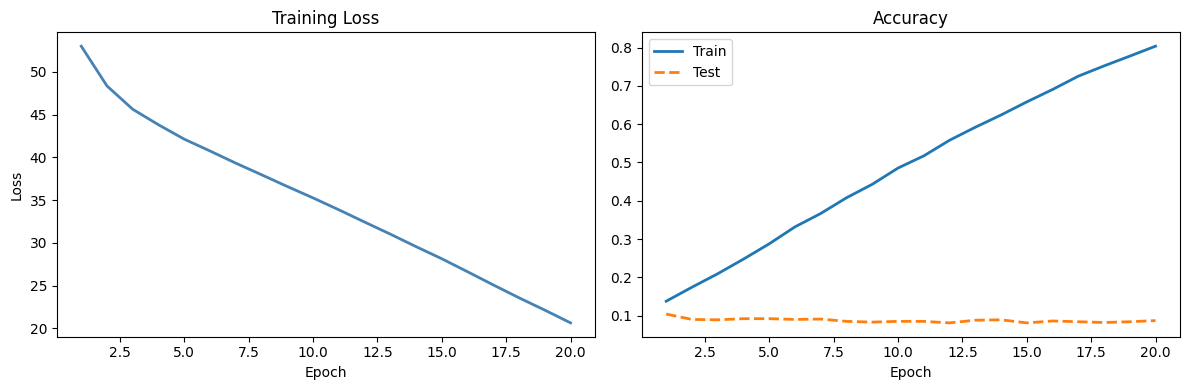


Final test accuracy: 0.087


In [10]:
class MLP_NumPy:
    def __init__(self, layer_dims, lr=0.01, seed=42):
        np.random.seed(seed)
        self.lr = lr
        self.params = {}
        for i in range(1, len(layer_dims)):
            # He initialisation for ReLU layers
            scale = np.sqrt(2.0 / layer_dims[i-1])
            self.params[f'W{i}'] = np.random.randn(layer_dims[i-1], layer_dims[i]) * scale
            self.params[f'b{i}'] = np.zeros(layer_dims[i])
        self.L = len(layer_dims) - 1

    def _forward(self, X):
        cache = {'A0': X}
        A = X
        for i in range(1, self.L + 1):
            W, b = self.params[f'W{i}'], self.params[f'b{i}']
            Z = A @ W + b
            cache[f'Z{i}'] = Z
            A = relu(Z) if i < self.L else softmax(Z)
            cache[f'A{i}'] = A
        return cache

    def _backward(self, cache, y_true):
        n = cache['A0'].shape[0]
        grads = {}
        delta = cache[f'A{self.L}'].copy()
        delta[range(n), y_true] -= 1
        delta /= n
        for i in range(self.L, 0, -1):
            A_prev = cache[f'A{i-1}']
            grads[f'dW{i}'] = A_prev.T @ delta
            grads[f'db{i}'] = delta.sum(axis=0)
            if i > 1:
                delta = (delta @ self.params[f'W{i}'].T) * relu_d(cache[f'Z{i-1}'])
        return grads

    def step(self, grads):
        for i in range(1, self.L + 1):
            self.params[f'W{i}'] -= self.lr * grads[f'dW{i}']
            self.params[f'b{i}'] -= self.lr * grads[f'db{i}']

    def predict(self, X):
        cache = self._forward(X)
        return cache[f'A{self.L}'].argmax(axis=1)

    def loss(self, X, y):
        cache = self._forward(X)
        return cross_entropy(cache[f'A{self.L}'], y)


# ── Synthetic MNIST-like data (replace with real MNIST via torchvision) ──
np.random.seed(0)
N_train, N_test, D, C = 5000, 1000, 784, 10
X_train = np.random.randn(N_train, D).astype(np.float32)
y_train = np.random.randint(0, C, N_train)
X_test  = np.random.randn(N_test,  D).astype(np.float32)
y_test  = np.random.randint(0, C, N_test)
print("Using synthetic data (shape mirrors MNIST 28×28)")
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# ── Training ──
model = MLP_NumPy([784, 128, 64, 10], lr=0.05)
batch_size = 256
n_epochs   = 20
history    = []

for epoch in range(n_epochs):
    # Shuffle
    idx = np.random.permutation(N_train)
    X_train, y_train = X_train[idx], y_train[idx]

    epoch_loss = 0
    for start in range(0, N_train, batch_size):
        Xb = X_train[start:start+batch_size]
        yb = y_train[start:start+batch_size]
        cache = model._forward(Xb)
        grads = model._backward(cache, yb)
        model.step(grads)
        epoch_loss += cross_entropy(cache[f'A{model.L}'], yb)

    train_acc = (model.predict(X_train) == y_train).mean()
    test_acc  = (model.predict(X_test)  == y_test ).mean()
    history.append((epoch_loss, train_acc, test_acc))
    if epoch % 4 == 0:
        print(f"Epoch {epoch+1:2d} | loss {epoch_loss:.3f} | "
              f"train {train_acc:.3f} | test {test_acc:.3f}")

# Plot training curve
epochs_ax = range(1, n_epochs+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_ax, [h[0] for h in history], 'steelblue', lw=2)
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs_ax, [h[1] for h in history], label='Train', lw=2)
ax2.plot(epochs_ax, [h[2] for h in history], label='Test',  lw=2, ls='--')
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("mlp_numpy_training.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"\nFinal test accuracy: {history[-1][2]:.3f}")

---

## What I Learned Today

**Perceptron** — A single neuron computes z = Wᵀx + b then applies σ(z). Multiple neurons in a layer process inputs in parallel using matrix math (X @ W + b).

**Activation functions** — Non-linearities are what make deep networks able to model complex functions. ReLU is the default choice: simple, fast gradient (0 or 1), no vanishing gradient for positive values.

**Forward pass** — Just repeated matrix multiply + activation. Each layer takes the previous layer's output and transforms it. Softmax at the end turns scores into probabilities.

**Backpropagation** — Chain rule applied backwards. Each layer computes: how does the loss change with respect to my weights? Answer: upstream_delta × my_input.T. The delta that flows back is: upstream_delta × my_weights.T × my_activation_derivative.

**He initialisation** — For ReLU networks, initialise weights with scale √(2/fan_in) to keep activation variance stable across layers. Xavier uses √(1/fan_in) and is better for tanh/sigmoid.

**Key equation to remember:**
```
W ← W - η · ∂L/∂W        (gradient descent step)
∂L/∂W = Aᵢ₋₁ᵀ · δᵢ       (weight gradient = prev_activation.T × delta)
δᵢ₋₁ = δᵢ · Wᵢᵀ ⊙ σ'(Zᵢ₋₁)   (delta flowing backward)
```